<h1 style="color: #25a890; font-size: 2.2em; margin-bottom: 5px; font-weight: 700;">Customer Segmentation | Modeling</h1>

<p style="margin: 3px 0; font-size: 1.1em; font-weight: 600;">NOVA IMS <span style="font-weight: 300;">| Machine Learning II</span></p>
<p style="margin: 3px 0; font-size: 0.95em;"><strong">Professors</strong> Fernando Bação & Ivo Bernardo</p>


<br>
<table style="width: 100%; border-collapse: collapse; font-size: 1em;">
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Diogo Gonçalves</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241817)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Gustavo Franco</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241806)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Simão Costa</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241772)</td>
    </tr>


    


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Table of Contents</h3>
<div style="font-family: Arial, sans-serif; line-height: 1.8; margin-bottom: 30px; padding-left: 10px;">
    <ol style="margin-top: 0; padding-left: 20px;">
        <li><a href="#library-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Library Imports</a></li>
        <li><a href="#data-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Imports</a></li>
        <li>
            <a href="#data-cleaning" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Cleaning</a>
            <ul style="list-style-type: circle; padding-left: 20px; margin-top: 5px; margin-bottom: 5px;">
                <li><a href="#duplicates" style="color: #25a890; text-decoration: none;">Missing Values</a></li>
                <li><a href="#variable-consistency" style="color: #25a890; text-decoration: none;">Transformation of Variables</a></li>
            </ul>
        </li>
        <li><a href="#correlation-between-variables" style="color: #25a890; text-decoration: none; font-weight: 500;">Correlation between variables</a></li>
    </ol>
</div>

In [1]:
# !pip install hdbscan minisom umap-learn

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Library Imports</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import hdbscan
from minisom import MiniSom
import umap

import warnings
warnings.filterwarnings('ignore')

c:\Users\simao\anaconda3\envs\Machine_Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Import</h2>

In [3]:
X_scaled = pd.read_csv('X_scaled.csv', index_col='customer_id')

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

<p style="color: #25a890; font-size: 0.9em;">To remove outliers that malfunction the code</p>

In [5]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
outlier_mask = iso.fit_predict(X_scaled) == 1
X_scaled_clean = X_scaled[outlier_mask]

print(f"Removed {(~outlier_mask).sum()} outliers, keeping {outlier_mask.sum()} customers")

Removed 331 outliers, keeping 32707 customers


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Elbow Method and Silhouette</h2>

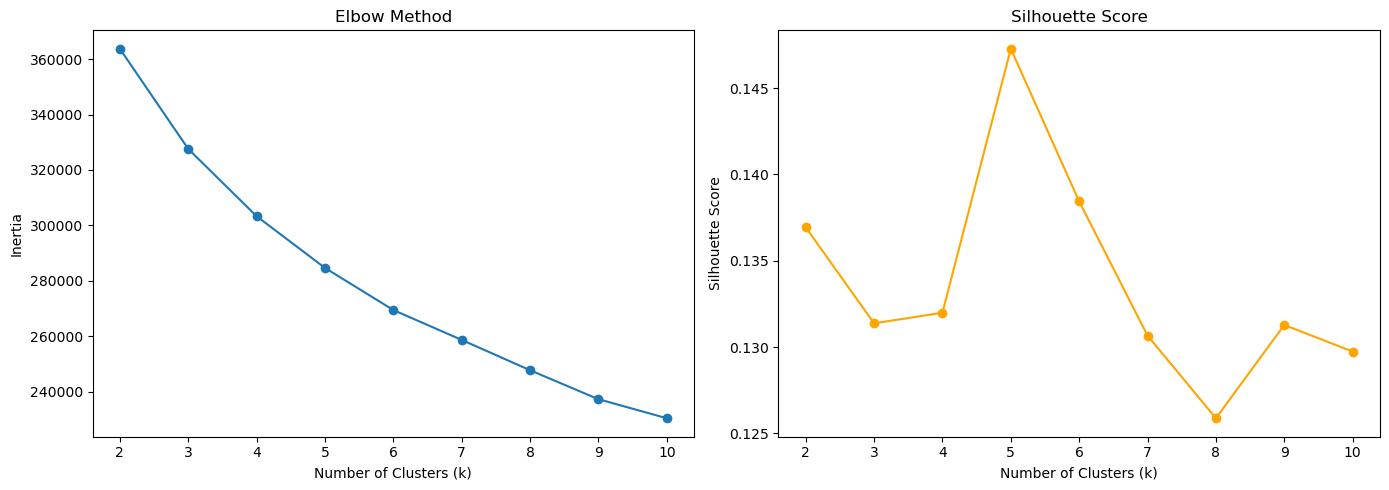

In [6]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_clean)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled_clean, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Models</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> K-means</h3>

In [7]:
# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_clean)
kmeans_score = silhouette_score(X_scaled_clean, kmeans_labels)
print(f"K-Means silhouette={kmeans_score:.3f}, clusters={len(set(kmeans_labels))}")

K-Means silhouette=0.147, clusters=5


In [8]:
X_scaled_outliers = X_scaled[~outlier_mask]
outlier_labels = kmeans.predict(X_scaled_outliers)

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> K-Medoids</h3>

In [9]:
# ── K-Medoids ──────────────────────────────────────────────────────────────
#kmedoids = KMedoids(n_clusters=4, random_state=42)
#kmedoids_labels = kmedoids.fit_predict(X_pca_clean)
#kmedoids_score = silhouette_score(X_pca_clean, kmedoids_labels)
#print(f"K-Medoids silhouette={kmedoids_score:.3f}, clusters={len(set(kmedoids_labels))}")

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Hierchical Clustering</h3>

In [10]:
# ── Agglomerative with different linkages ──────────────────────────────────
linkages = ['ward', 'complete', 'average', 'single']

for linkage_method in linkages:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage_method)
    agg_labels = agg.fit_predict(X_scaled_clean)
    score = silhouette_score(X_scaled_clean, agg_labels)
    print(f"Agglomerative ({linkage_method:<10})  silhouette={score:.3f}")

Agglomerative (ward      )  silhouette=0.116
Agglomerative (complete  )  silhouette=0.112
Agglomerative (average   )  silhouette=0.339
Agglomerative (single    )  silhouette=0.319


In [11]:
# ── Dendrogram to visualize structure ──────────────────────────────────────
#linked = linkage(X_pca, method='ward') # Can be 'ward', 'complete', 'average', 'single'

#plt.figure(figsize=(12, 5))
#dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45)
#plt.title('Dendrogram (Ward Linkage)')
#plt.xlabel('Sample index')
#plt.ylabel('Distance')
#plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> DBSCAN</h3>

In [12]:
# ── DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled_clean)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_scaled_clean, dbscan_labels)
    print(f"DBSCAN         silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"DBSCAN         clusters={n_clusters}  noise={n_noise}  (tune eps/min_samples)")

DBSCAN         silhouette=-0.118  clusters=4  noise=32682


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> HDBSCAN</h3>

In [13]:
# ── HDBSCAN ────────────────────────────────────────────────────────────────
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
hdb_labels = hdb.fit_predict(X_scaled_clean)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_scaled_clean, hdb_labels)
    print(f"HDBSCAN        silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"HDBSCAN        clusters={n_clusters}  noise={n_noise}  (tune min_cluster_size)")

HDBSCAN        silhouette=0.131  clusters=2  noise=2688


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Self Organizing Map</h3>

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 2.199776903297682
SOM + KMeans   silhouette=0.109  clusters=4


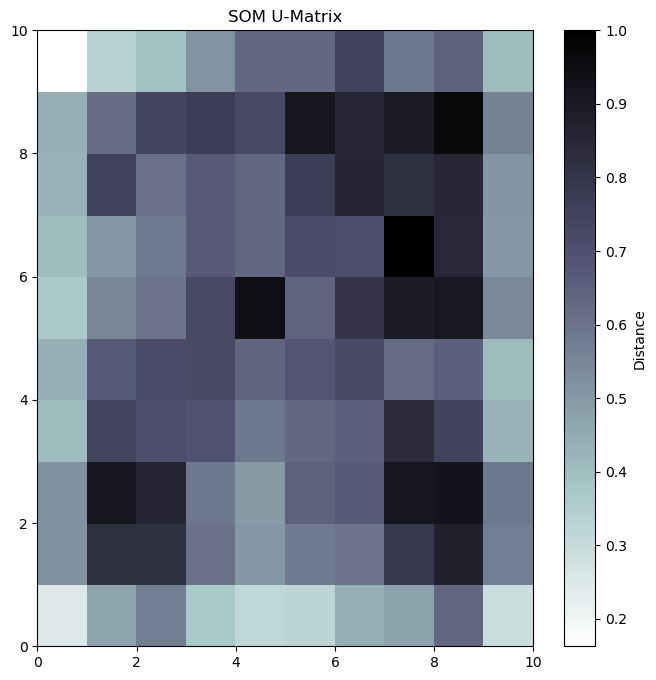

In [14]:
# ── Train SOM ──────────────────────────────────────────────────────────────
som_x, som_y = 10, 10
som = MiniSom(
    x=som_x, y=som_y,
    input_len=X_scaled_clean.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

X_scaled_array = X_scaled_clean.values  # convert to numpy

som.random_weights_init(X_scaled_array)
som.train(X_scaled_array, num_iteration=10000, verbose=True)

# ── Assign each customer to a neuron ───────────────────────────────────────
winner_coordinates = np.array([som.winner(x) for x in X_scaled_array])

# ── Map neurons to k=4 clusters using K-Means on neuron weights ────────────
weights = som.get_weights().reshape(-1, X_scaled_array.shape[1])
kmeans_som = KMeans(n_clusters=4, random_state=42, n_init=10)
neuron_labels = kmeans_som.fit_predict(weights)

som_labels = np.array([neuron_labels[x * som_y + y] for x, y in winner_coordinates])

score = silhouette_score(X_scaled_array, som_labels)
print(f"SOM + KMeans   silhouette={score:.3f}  clusters={len(set(som_labels))}")

# ── U-Matrix visualization ─────────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title('SOM U-Matrix')
plt.show()


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Visualization</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> T-SNE</h3>

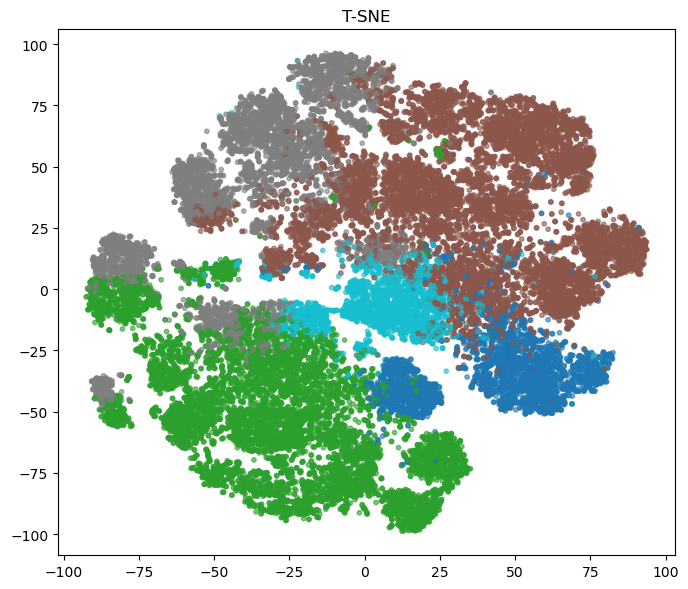

In [15]:
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled_clean)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
ax.set_title('T-SNE')
plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> UMAP</h3>

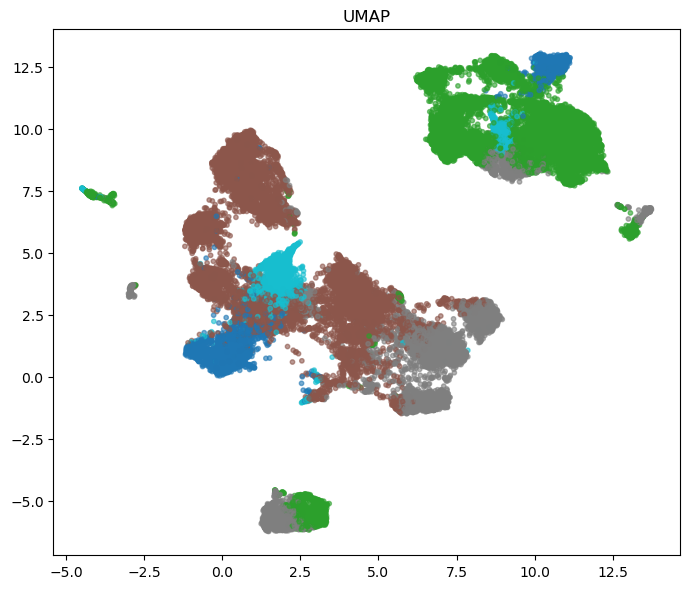

In [16]:
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled_clean)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
ax.set_title('UMAP')
plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> PCA</h3>

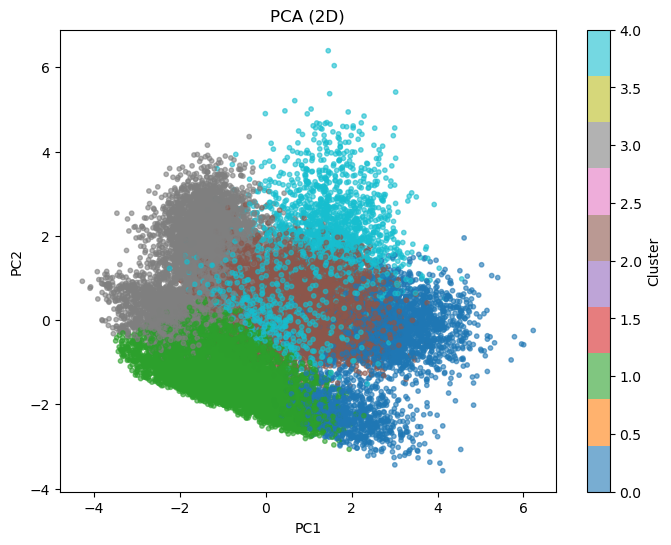

In [17]:
scaled_2d = PCA(n_components=2, random_state=42)
X_scaled_2d = scaled_2d.fit_transform(X_scaled_clean)

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled_2d[:, 0], X_scaled_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
plt.title('PCA (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()

In [18]:
for cluster, count in sorted(Counter(kmeans_labels).items()):
    print(f"Cluster {cluster} has {count} rows")

Cluster 0 has 3206 rows
Cluster 1 has 9997 rows
Cluster 2 has 11246 rows
Cluster 3 has 6030 rows
Cluster 4 has 2228 rows


In [19]:
cust_info=pd.read_csv('cust_info_engineered.csv')
cust_info=cust_info.set_index('customer_id')
cluster_features = [
    'age',
    'year_first_transaction',
    'progenitores',
    'spend_per_store',
    'fresh_food_ratio',
    'lifetime_spend_groceries',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_hygiene',
    'lifetime_spend_petfood',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion',
    'distinct_stores_visited',
    'promotion_guy',
    'healthy_guy',
    'tech_enthusiast',
    'has_loyalty_card',
    'loyal_long_timer',
]

In [20]:
all_labels = np.empty(len(X_scaled), dtype=int)
all_labels[outlier_mask] = kmeans_labels
all_labels[~outlier_mask] = outlier_labels

In [21]:
cluster_means = cust_info[cluster_features].copy().reset_index(drop=True)
cluster_means['cluster'] = all_labels
cluster_means.groupby('cluster')[cluster_features].mean().round(2).head(20)

,age,year_first_transaction,progenitores,spend_per_store,fresh_food_ratio,lifetime_spend_groceries,lifetime_spend_alcohol_drinks,lifetime_spend_nonalcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,distinct_stores_visited,promotion_guy,healthy_guy,tech_enthusiast,has_loyalty_card,loyal_long_timer
cluster,,,,,,,,,,,,,,,,,,
0,56.80,2013.29,5.95,11570.53,0.21,25614.25,1455.20,849.43,935.68,362.83,311.96,0.21,3.19,5295.22,0.13,0.34,0.71,9.07
1,54.31,2016.07,1.57,5805.69,0.51,13128.75,604.18,440.39,787.82,328.83,134.41,0.24,3.13,3059.15,0.37,0.87,0.01,0.00
2,57.79,2014.56,1.62,7033.23,0.49,14638.55,477.43,472.41,962.44,359.01,137.02,0.19,2.88,2616.68,0.36,0.90,1.00,11.44
3,46.65,2017.00,1.45,3927.30,0.28,10878.02,440.75,205.21,418.07,281.44,68.87,0.71,3.48,7728.61,0.14,0.27,0.73,6.82
4,57.81,2013.25,1.86,12369.36,0.07,39814.40,696.78,669.95,1141.66,360.39,252.57,0.62,3.87,23410.06,0.04,0.11,0.79,10.30


0- Big Family Shopper

1- Bargain Hunter

2- Most Loyal

3- New Costumers + Tech Enthusiast

4- Biggest Buyers (with Promotion)

In [22]:
result = pd.DataFrame({
    'customer_id': X_scaled.index,
    'cluster': all_labels
})

result.to_csv('cluster_assignments.csv', index=False)
print(f"Saved {len(result)} customers")

Saved 33038 customers


In [23]:
print(f"Total customers in original data: {len(X_scaled)}")
print(f"Total customers in output: {len(result)}")
print(result['cluster'].value_counts().sort_index())

Total customers in original data: 33038
Total customers in output: 33038
cluster
0     3248
1    10104
2    11347
3     6056
4     2283
Name: count, dtype: int64
